# Exploratory Data Analysis (EDA): ETH/USDT Microstructure & Volatility
**Objective:** Validate the integrity of the 5-minute Binance dataset, visualize the non-stationary nature of raw prices vs. stationary log returns, prove the existence of volatility clustering, and analyze cross-asset correlations (ETH vs. BTC).

In [6]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add the src directory to the Python path so we can import our custom modules
sys.path.append(os.path.abspath('../src'))
from data_pipeline.preprocessor import MarketDataPreprocessor

# Plotting style configuration for quant research
plt.style.use('dark_background')
sns.set_palette("muted")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## 1. Data Loading & Grid Verification
First, we load the raw ETH-USDT data downloaded via our pipeline. We will immediately pass it through the `MarketDataPreprocessor` to force a continuous time grid and calculate log returns.

In [8]:
# Initialize our custom preprocessor
preprocessor = MarketDataPreprocessor()

# Load the raw training data (Phase 1: Pre-2026)
raw_data_path = '../data/raw/ETHUSDT_5m_2024-01-01_to_2026-01-01.csv'

if not os.path.exists(raw_data_path):
    print(f"File not found at {raw_data_path}. Please run src/data_pipeline/fetch_binance.py first.")
else:
    df_raw = pd.read_csv(raw_data_path, index_col=0, parse_dates=True)
    print(f"Raw Data Loaded. Shape: {df_raw.shape}")
    
    # 1. Force Time Grid (Fill missing API gaps)
    df_grid = preprocessor.force_time_grid(df_raw, interval='5min')
    
    # 2. Compute Log Returns
    df = preprocessor.compute_log_returns(df_grid)
    
    display(df[['close', 'volume_usdt', 'trade_count', 'log_return']].head())

2026-06-21 22:39:22,137 - INFO - Forcing continuous time grid...
2026-06-21 22:39:22,144 - INFO - Grid fill complete. Final shape: (210529, 9)
2026-06-21 22:39:22,144 - INFO - Computing Log Returns...


Raw Data Loaded. Shape: (210529, 9)


,close,volume_usdt,trade_count,log_return
2024-01-01 00:05:00+00:00,2290.77,3.785227e+06,3354,0.001280
2024-01-01 00:10:00+00:00,2296.71,4.197682e+06,3321,0.002590
2024-01-01 00:15:00+00:00,2292.36,2.044781e+06,2332,-0.001896
2024-01-01 00:20:00+00:00,2294.67,1.751663e+06,2029,0.001007
2024-01-01 00:25:00+00:00,2291.05,2.373492e+06,2332,-0.001579


## 2. Price Non-Stationarity vs. Return Stationarity
Neural networks fail when fed raw prices because prices trend to infinity (non-stationary). We must visualize why `log_return` is our foundational feature.

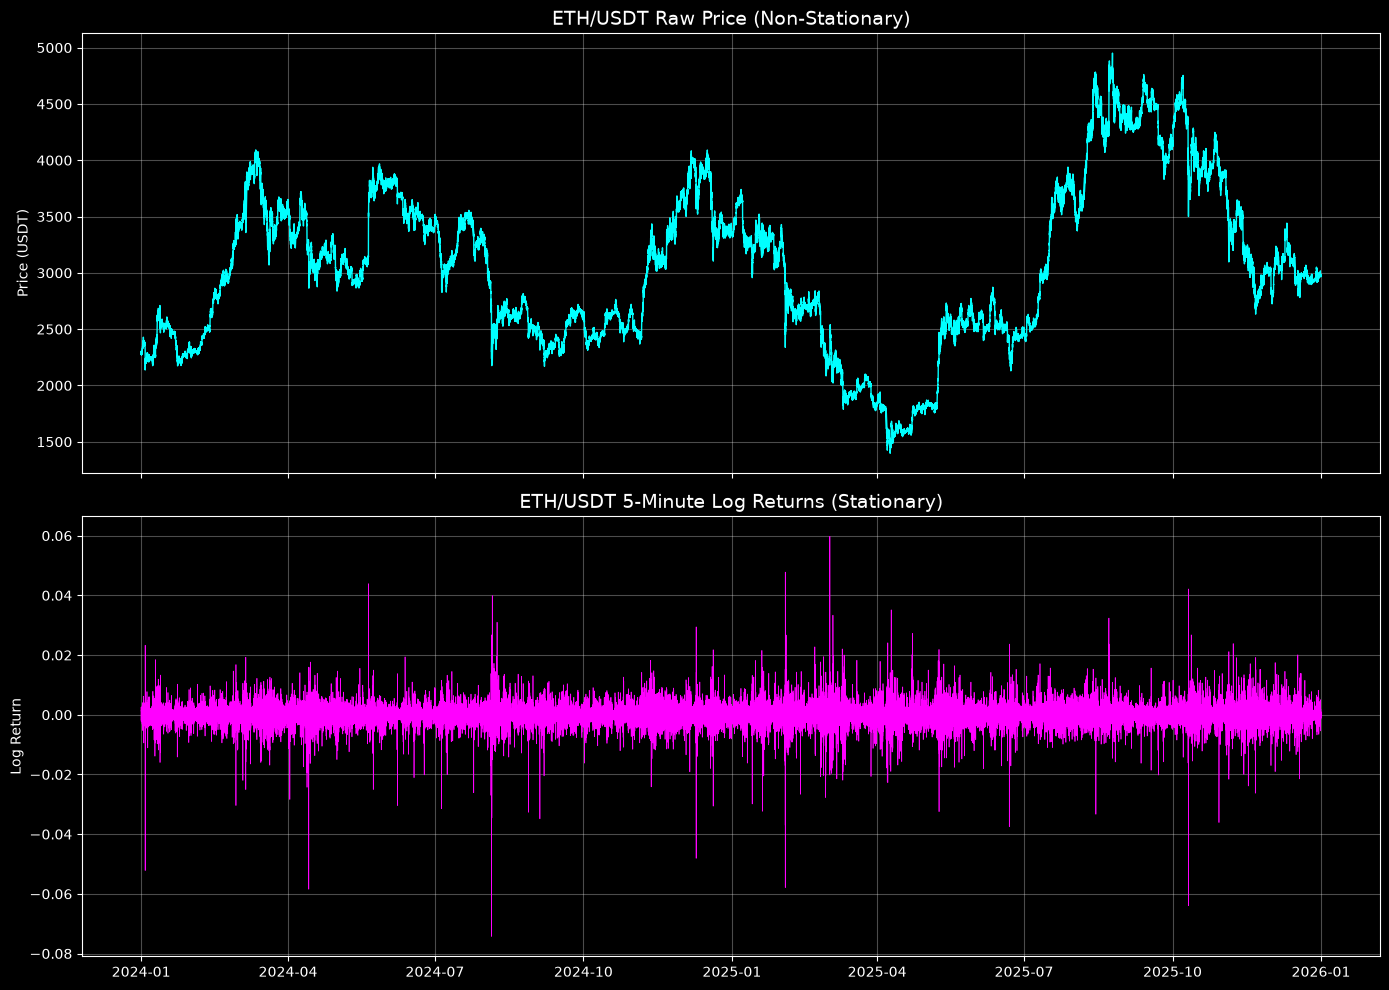

In [9]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Plot Raw Price
ax1.plot(df.index, df['close'], color='cyan', linewidth=1)
ax1.set_title('ETH/USDT Raw Price (Non-Stationary)', fontsize=14)
ax1.set_ylabel('Price (USDT)')

# Plot Log Returns
ax2.plot(df.index, df['log_return'], color='magenta', linewidth=0.5)
ax2.set_title('ETH/USDT 5-Minute Log Returns (Stationary)', fontsize=14)
ax2.set_ylabel('Log Return')

plt.tight_layout()
plt.show()

## 3. Volatility Clustering (The ARCH Effect)
The entire premise of our project relies on the fact that volatility is predictable because it *clusters*. Calm periods follow calm periods, and violent periods follow violent periods. Let's calculate and plot the 1-day rolling standard deviation ($\sigma$) to prove this visually.

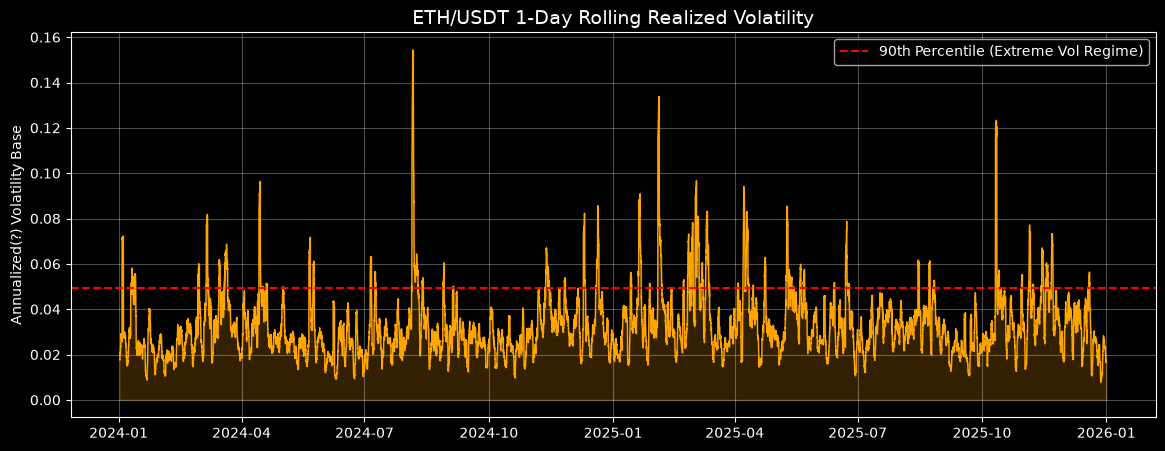

In [10]:
# Calculate 1-Day Rolling Realized Volatility (288 5-min bars = 24 hours)
df['rolling_vol_1d'] = df['log_return'].rolling(window=288).std() * np.sqrt(288)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df['rolling_vol_1d'], color='orange', linewidth=1)
ax.set_title('ETH/USDT 1-Day Rolling Realized Volatility', fontsize=14)
ax.set_ylabel('Annualized(?) Volatility Base')
ax.fill_between(df.index, df['rolling_vol_1d'], color='orange', alpha=0.2)

# Highlight high-volatility regimes
threshold = df['rolling_vol_1d'].quantile(0.90)
ax.axhline(threshold, color='red', linestyle='--', label='90th Percentile (Extreme Vol Regime)')
ax.legend()

plt.show()

## 4. Heavy Tails & Market Microstructure
Financial returns are not perfectly Gaussian (Normal). They have "fat tails" (kurtosis), meaning extreme events happen far more often than standard statistics predict. Let's look at the distribution of returns and a microstructure feature (Volume).

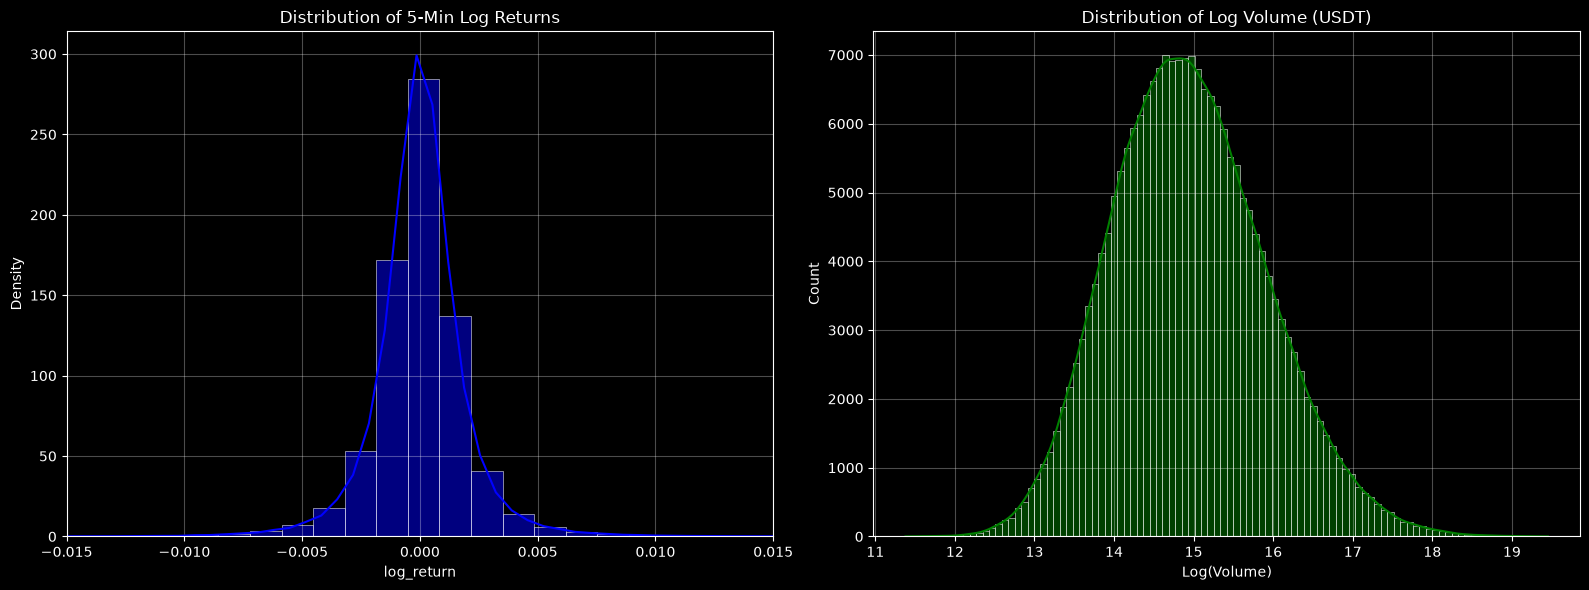

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Return Distribution vs Normal Distribution
sns.histplot(df['log_return'].dropna(), bins=100, kde=True, ax=ax1, color='blue', stat='density')
ax1.set_xlim(-0.015, 0.015)
ax1.set_title('Distribution of 5-Min Log Returns', fontsize=12)

# Volume distribution (Log Scale)
sns.histplot(df['log_volume_usdt'].dropna(), bins=100, kde=True, ax=ax2, color='green')
ax2.set_title('Distribution of Log Volume (USDT)', fontsize=12)
ax2.set_xlabel('Log(Volume)')

plt.tight_layout()
plt.show()

## 5. Multi-Asset Correlation (ETH vs. BTC)
*Optional step: If you downloaded BTC data, uncomment and run this cell to see how closely ETH volatility maps to BTC volatility. High correlation confirms we can use cross-asset features to improve the LSTM's predictive power.*

Loading BTC data for correlation check...


2026-06-21 22:50:02,457 - INFO - Forcing continuous time grid...
2026-06-21 22:50:02,462 - INFO - Grid fill complete. Final shape: (166753, 9)
2026-06-21 22:50:02,463 - INFO - Computing Log Returns...


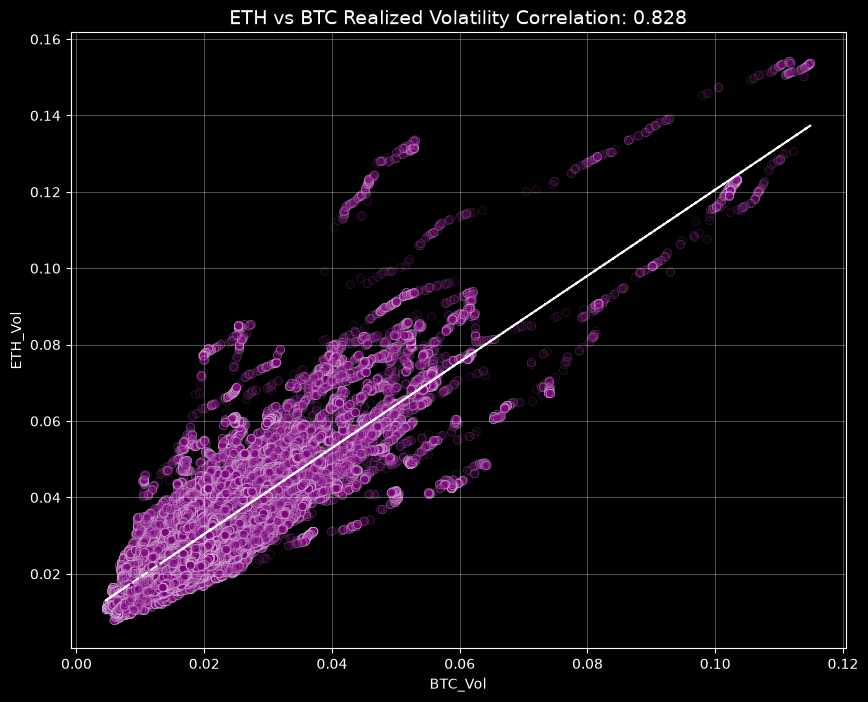

In [14]:
btc_data_path = '../data/raw/BTCUSDT_5m_2024-06-01_to_2026-01-01.csv'

if os.path.exists(btc_data_path):
    print("Loading BTC data for correlation check...")
    df_btc_raw = pd.read_csv(btc_data_path, index_col=0, parse_dates=True)
    df_btc = preprocessor.force_time_grid(df_btc_raw, interval='5min')
    df_btc = preprocessor.compute_log_returns(df_btc)
    
    # Calculate BTC rolling volatility
    df_btc['btc_rolling_vol'] = df_btc['log_return'].rolling(window=288).std()
    
    # Merge on index
    merged_vol = pd.DataFrame({
        'ETH_Vol': df['rolling_vol_1d'],
        'BTC_Vol': df_btc['btc_rolling_vol'] * np.sqrt(288)
    }).dropna()
    
    # Calculate Correlation
    corr = merged_vol.corr().iloc[0, 1]
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.scatterplot(x='BTC_Vol', y='ETH_Vol', data=merged_vol, alpha=0.1, color='purple', ax=ax)
    ax.set_title(f'ETH vs BTC Realized Volatility Correlation: {corr:.3f}', fontsize=14)
    
    # Add trendline
    m, b = np.polyfit(merged_vol['BTC_Vol'], merged_vol['ETH_Vol'], 1)
    ax.plot(merged_vol['BTC_Vol'], m*merged_vol['BTC_Vol'] + b, color='white', linestyle='--')
    
    plt.show()
else:
    print("BTC data not found. Skipping correlation check.")